# Trader Metrics

No API keys, no trades. This chapter is a read-only daily scan over public market data, sharing Chapter Three's data spine.

1. Data comes from the survivorship-complete 1h archives at `data.binance.vision` (the same source Chapter Three builds on), loaded offline and resampled to daily; `ccxt` is an optional live top-up only.
2. Indicators are derived with `pandas-ta-classic`; the aligned baseline is the triple-Supertrend used by the live bot and scored in Chapter Three.

### Supertrend Integration

The triple-Supertrend from the live bot (`inputs/supertrend.py`) is the aligned baseline for this chapter: three ATR-channel bands (periods 12/3, 10/1, 11/2) must agree on an uptrend, gated by EMA-200. The scan computes it per coin (`ST_buy`, `ST_agree`) and ranks on it first, so Chapter One and Chapter Three share one benchmark rather than each carrying a different rule set. The older indicator flags (AMAT, EMA-vs-Kalman, the Kalman level) stay on the board as context, explicitly illustrative.

How and where the same signal is used downstream:
- **Features** -> `inputs/build_dataset_1h.py` `supertrend_block()` emits the `f_st_` family (band agreement, signed band distances, reversal flip, EMA-200 distance), consumed by the Chapter Three model. Causal and scale-invariant, like every other `f_` feature.
- **Benchmark** -> the bot's entry/exit rules are scored after fees in `inputs/baseline_supertrend_1h.py` (Chapter Three, Stability) and resampled by the Monte Carlo robustness gate.
- **Full record** -> `tasks/integration-2026-06-23-claudetrader-supertrend.md`.

## Design Update

Chapter One is the **metrics layer**: the indicator board and the baseline scoring that rank coins on a daily scan. As of this revision it reads the SAME data spine as Chapter Three. Price comes from the survivorship-complete 1h archives at `data.binance.vision` (every USDT pair ever listed, including delisted ones), resampled to daily, and the universe is drawn from Chapter Three's point-in-time Stage B screen rather than a live top-N by today's volume. That removes the survivorship bias the old live scan carried at the universe level, where it only ever saw the coins that are large today.

The decision-grade evaluation lives in Chapter Three: an ATR-scaled triple-barrier label, a walk-forward split, the model zoo, and the after-fee, out-of-sample scoreboard. The scores here are an **illustrative, not-yet-validated** read of the signal stack, a place to build intuition and eyeball candidates, not a trade trigger. Where the two chapters share a rules benchmark it is the same triple-Supertrend the live bot trails and Chapter Three scores after fees, so the chapters tell one story instead of running different rule sets in each.

### Environment Setup

Dependencies are pinned in `inputs/requirements.txt` and reinstalled on each fresh kernel. The core libraries are `pandas-ta-classic` (indicators), `pykalman` (smoothing), `plotly` (interactive charts), and `matplotlib` (the shared exit-geometry view from Chapter Three); `ccxt` is kept only for the optional live top-up. Price history and the universe come from Chapter Three's offline archives through `build_dataset_1h`, so no exchange login or API key is needed to run the scan. Run the setup cell below once per session.

In [1]:
import sys, subprocess
from pathlib import Path

# assign Python kernel,
REQUIRED_PY = (3, 11)
if sys.version_info[:2] != REQUIRED_PY: raise RuntimeError(
        f"This notebook needs Python {REQUIRED_PY[0]}.{REQUIRED_PY[1]}, "
        f"but the kernel is {sys.version.split()[0]}. Switch the kernel and re-run.")

# Install packages & versions in requirements.txt
REQUIREMENTS = Path("../inputs/requirements.txt")
if not REQUIREMENTS.exists():
    raise FileNotFoundError(f"{REQUIREMENTS} not found — run from the repo root.")
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
     "--break-system-packages", "--disable-pip-version-check",
     "-r", str(REQUIREMENTS)], check=True,)

# import package modules and naming
import warnings, numpy as np, pandas as pd
from datetime import datetime
import ccxt
import pandas_ta_classic as ta
from pykalman import KalmanFilter
import plotly, plotly.graph_objects as go, plotly.io as pio
warnings.filterwarnings("ignore")
pio.renderers.default = "plotly_mimetype+notebook_connected"  

# quick sanity check
print(f"Environment ready  ·  python {sys.version.split()[0]}  ({sys.executable})")
print(f"  ccxt {ccxt.__version__} · pandas {pd.__version__} · "
      f"numpy {np.__version__} · plotly {plotly.__version__}")

Environment ready  ·  python 3.11.13  (/Users/seamus/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/bin/python)
  ccxt 4.5.59 · pandas 2.3.3 · numpy 2.4.6 · plotly 6.8.0


### Data Sources and Provenance

This chapter reads the SAME data spine as Chapter Three. Price comes from the survivorship-complete 1h archives at `data.binance.vision` (official monthly per-symbol OHLCV zips, exchange-direct and checksummed, every USDT pair ever listed including delisted ones), loaded offline through `build_dataset_1h` and resampled to daily in `load_daily()`. This replaces the old live ccxt top-N-by-volume scan, which was survivorship-biased at the universe level. `ccxt` remains an optional live top-up for the still-forming day, never the historical record.

The frames Chapter Three builds, each its own dataset:

| frame | raw klines | built dataset | role |
| --- | --- | --- | --- |
| 5m (2026-06-24) | `klines_5m/` | `dataset_5m_allmarket.parquet` | scalp probe (curated coins) |
| 1h | `klines_1h/` | `dataset_1h_allmarket.parquet` | original day-trade frame; this scan resamples it to daily |
| 4h (2026-06-23) | `klines_4h/` | `dataset_4h_allmarket.parquet` | coarser frame where after-fee edge may survive |
| daily (planned) | resampled here | next in the plan | trend / context frame |

The universe is Chapter Three's point-in-time Stage B screen, not a live volume ranking, so a candidate that scans well here is drawn from the same screened, survivorship-complete set the model is evaluated on. The cell below proves the source by pulling one month of archive bars directly.

In [2]:
# Demo: how each frame is downloaded, and from where. Every frame sources the SAME official Binance
# public archive at data.binance.vision -- monthly per-symbol OHLCV kline zips, one file per interval,
# exchange-direct and checksummed (NOT a live API). ccxt is only a live top-up for the bar still
# forming. This cell pulls one month at 1h, 4h and 5m to prove the source and format; the full pull is
# the commands in the table.
import io, zipfile, urllib.request, pandas as pd
BINANCE_VISION = "https://data.binance.vision/"
def vision_url(symbol, interval, month):
    return f"{BINANCE_VISION}data/spot/monthly/klines/{symbol}/{interval}/{symbol}-{interval}-{month}.zip"

provenance = pd.DataFrame([
    ("1h  (old)", "acquire_vision.py download --interval 1h", "klines_1h/<SYM>/", "dataset_1h_allmarket.parquet"),
    ("1d  (old)", "flow_data.py --interval 1d --all-market",  "klines/<SYM>/",    "daily_flow.csv"),
    ("4h  (new)", "acquire_vision.py download --interval 4h", "klines_4h/<SYM>/", "dataset_4h_allmarket.parquet"),
    ("5m  (new)", "acquire_vision.py download --interval 5m --symbols <scalp set>", "klines_5m/<SYM>/", "dataset_5m_allmarket.parquet"),
], columns=["frame", "download command", "raw klines on disk", "built dataset"])
print("Survivorship-complete: acquire_vision.py crawl enumerates EVERY symbol ever listed (incl.")
print("delisted), so dead coins are not silently dropped the way the exchangeInfo path is.\n")
print(provenance.to_string(index=False))

print("\nLIVE proof of source + format (one month of BTCUSDT, straight from the archive):")
for interval in ("1h", "4h", "5m"):
    u = vision_url("BTCUSDT", interval, "2024-01")
    try:
        raw = urllib.request.urlopen(u, timeout=15).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        bars = pd.read_csv(io.BytesIO(z.read(z.namelist()[0])), header=None).iloc[:, :6]
        bars.columns = ["open_time", "open", "high", "low", "close", "volume"]
        print(f"  {interval:3s}: {len(bars):5d} bars, {len(raw)/1024:5.0f} KB  <-  {u}")
    except Exception as e:
        print(f"  {interval:3s}: offline ({e}); full archive lives under inputs/binance-data/klines_{interval}/")

Survivorship-complete: acquire_vision.py crawl enumerates EVERY symbol ever listed (incl.
delisted), so dead coins are not silently dropped the way the exchangeInfo path is.

    frame                                               download command raw klines on disk                built dataset
1h  (old)                       acquire_vision.py download --interval 1h   klines_1h/<SYM>/ dataset_1h_allmarket.parquet
1d  (old)                        flow_data.py --interval 1d --all-market      klines/<SYM>/               daily_flow.csv
4h  (new)                       acquire_vision.py download --interval 4h   klines_4h/<SYM>/ dataset_4h_allmarket.parquet
5m  (new) acquire_vision.py download --interval 5m --symbols <scalp set>   klines_5m/<SYM>/ dataset_5m_allmarket.parquet

LIVE proof of source + format (one month of BTCUSDT, straight from the archive):
  1h :   744 bars,    42 KB  <-  https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h/BTCUSDT-1h-2024-01.zip
  4h :   186 bars,

### Import Data

Price data is the survivorship-complete 1h archive from `data.binance.vision` (exchange-direct monthly OHLCV zips, checksummed, the same source Chapter Three builds on), loaded offline through `build_dataset_1h` and resampled to daily in `load_daily()`. The universe is the point-in-time screened set from Chapter Three's Stage B profile, not a live top-N by today's volume, so delisted and thin coins are handled the way Chapter Three handles them rather than silently dropped. `ccxt` stays available as an optional live top-up for the still-forming day (`LIVE_TOPUP`), but it is not the source of the history or the universe. The knobs below, `TIMEFRAME`, `LIMIT`, `SCAN_N`, and `LIVE_TOPUP`, shape the scan, not where the data comes from.

In [3]:
# Data spine: Chapter Three's survivorship-complete 1h archives (data.binance.vision -- every USDT pair
# ever listed, incl. delisted), resampled to daily here. This REPLACES the old live ccxt top-20-by-volume
# scan, which was survivorship-biased at the universe level (it only ever saw today's big coins, was
# point-in-time blind, and so disagreed with the evaluation universe in Chapter Three). ccxt is kept only
# as an OPTIONAL live top-up for the still-forming day; the universe and the history come from the archives.
import os, sys
for _up in (".", "..", "../.."):                       # make inputs/ importable regardless of cwd
    _cand = os.path.abspath(os.path.join(_up, "inputs"))
    if os.path.isdir(_cand):
        sys.path.insert(0, _cand); break
import build_dataset_1h as bd                           # Chapter Three's loader, Supertrend bands, screen

H1_ROOT    = os.path.join(bd.BINANCE_DATA, "klines_1h") # survivorship-complete 1h archives (~600 coins)
TIMEFRAME  = "1d"          # scan frame; daily bars are resampled from the 1h archives in load_daily()
LIMIT      = 400           # daily bars kept per coin for the indicator board
SCAN_N     = 20            # screened coins shown on the board (a display cap, NOT the universe filter)
LIVE_TOPUP = False         # True = append the forming day's bar from ccxt (needs network); archives are closed bars

def load_daily(symbol, limit=LIMIT):
    """Daily OHLCV for one coin, resampled from the survivorship-complete 1h archives (no live fetch).
    `symbol` may be 'BTC/USDT' or 'BTCUSDT'. Returns a datetime-indexed OHLCV frame of the last `limit`
    closed daily bars -- the same data Chapter Three screens and models, just aggregated to the day."""
    o = bd.load_coin(H1_ROOT, symbol.replace("/", ""))
    if o.empty:
        raise FileNotFoundError(f"no 1h archive for {symbol} under {H1_ROOT}")
    o = o.set_index("datetime").sort_index()
    d = o.resample("1D").agg({"open": "first", "high": "max", "low": "min",
                              "close": "last", "volume": "sum"}).dropna()
    return d.tail(limit)

exchange = getattr(ccxt, "binance")()                  # public client, kept ONLY for the optional live top-up
exchange.set_sandbox_mode(False)
print(f"Data spine: survivorship-complete 1h archives -> {TIMEFRAME} bars  |  {LIMIT} bars/coin  |  "
      f"board top {SCAN_N}  |  live top-up {LIVE_TOPUP}")

Data spine: survivorship-complete 1h archives -> 1d bars  |  400 bars/coin  |  board top 20  |  live top-up False


In [4]:
def calculate_indicator(symbol, limit=LIMIT):
    df = load_daily(symbol, limit)                                   # daily OHLCV from the survivorship 1h archives
    if LIVE_TOPUP:                                                   # optional: append the still-forming day (ccxt)
        try:
            b = exchange.fetch_ohlcv(symbol, timeframe="1d", limit=2)[-1]
            df.loc[pd.to_datetime(b[0], unit="ms")] = {"open": b[1], "high": b[2], "low": b[3],
                                                       "close": b[4], "volume": b[5]}
        except Exception:
            pass
    close, low = df["close"].iloc[-1], df["low"].iloc[-1]

    # Kalman threshold & smoother
    kf = KalmanFilter(transition_matrices=[1], observation_matrices=[1],
                      initial_state_mean=0, initial_state_covariance=1,
                      observation_covariance=1, transition_covariance=.01)
    state_means, _ = kf.filter(df["close"].values)
    df["kf_mean"] = state_means
    kalman = df["kf_mean"].iloc[-1]
    above_kalman = bool(low > kalman)

    # Trend: Is EMA-14 leading the Kalman mean?
    df.ta.ema(length=14, append=True)
    ema_cross = bool(df["EMA_14"].iloc[-1] > kalman)

    # Bollinger(14) mean-reversion envelope.
    bb = df.ta.bbands(length=14)
    bbl, bbu = bb["BBL_14_2.0"].iloc[-1], bb["BBU_14_2.0"].iloc[-1]

    # Ichimoku projections.
    ich = df.ta.ichimoku()[1]
    isa_9, isb_26 = ich["ISA_9"].iloc[-1], ich["ISB_26"].iloc[-1]

    # Archer MA trend flag, RSI, Choppiness.
    amat = bool(df.ta.amat()["AMATe_LR_8_21_2"].iloc[-1] == 1)
    rsi = float(df.ta.rsi().iloc[-1])
    chop = round(float(df.ta.chop().iloc[-1]), 2)

    # Candle shape check: any doji / dragonfly / gravestone candles?
    o, h, l, c = df["open"].iloc[-1], df["high"].iloc[-1], df["low"].iloc[-1], df["close"].iloc[-1]
    rng   = h - l
    body  = abs(c - o)
    upper = h - max(o, c)
    lower = min(o, c) - l
    doji       = bool(rng > 0 and body <= 0.10 * rng)
    dragonfly  = bool(doji and lower >= 0.6 * rng and upper <= 0.10 * rng)
    gravestone = bool(doji and upper >= 0.6 * rng and lower <= 0.10 * rng)

    # MACD (12,26,9)
    macd_line   = df["close"].ewm(span=12, adjust=False).mean() - df["close"].ewm(span=26, adjust=False).mean()
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    macd, sig           = macd_line.iloc[-1], signal_line.iloc[-1]
    macd_prev, sig_prev = macd_line.iloc[-2], signal_line.iloc[-2]
    macd_buy  = bool(macd_prev <= sig_prev and macd > sig)
    macd_sell = bool(macd_prev >= sig_prev and macd < sig)
    macd_below_zero = bool(macd < 0)

    # Triple-Supertrend baseline -- Chapter Three's actual rules benchmark (the three bands the live bot
    # trails) plus the EMA-200 filter, so the two chapters share ONE baseline. 3/3 bands up AND price above
    # EMA-200 = long. This, not the indicator votes below, is the aligned benchmark; the votes stay context.
    _ups = np.array([bd._supertrend_band(df, p, m)[0] for p, m in bd.ST_BANDS])
    _ema200 = df["close"].ewm(span=bd.ST_EMA, adjust=True).mean()
    st_agree = int(_ups[:, -1].sum())
    st_buy = bool(st_agree == 3 and close > _ema200.iloc[-1])

    buy  = amat and ema_cross and above_kalman
    sell = (not amat) and (not ema_cross) and (not above_kalman)
    row = dict(Symbol=symbol, ST_buy=st_buy, ST_agree=st_agree, Buy=buy, Sell=sell,
               Close=round(float(close), 4),
               RSI=round(rsi, 2), Chop=chop, AMAT=amat,
               Ichimoku_9=round(float(isa_9), 4), Ichimoku_26=round(float(isb_26), 4),
               EMA_gt_Kalman=ema_cross, Low_gt_Kalman=above_kalman,
               Doji=doji, Dragonfly=dragonfly, Gravestone=gravestone,
               MACD=round(float(macd),4), MACD_Signal=round(float(sig),4),
               MACD_Buy=macd_buy, MACD_Sell=macd_sell, MACD_below_zero=macd_below_zero)

    return df, row

def plot(symbol):
    from plotly.subplots import make_subplots
    df, _ = calculate_indicator(symbol)
    # price (candles + Kalman + EMA-14) on top, a volume histogram beneath, coloured by candle
    # direction and sharing the x-axis -- the OHLCV + volume view used across the chapters.
    vol_col = ["#26a69a" if c >= o else "#ef5350" for o, c in zip(df.open, df.close)]
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                        row_heights=[0.78, 0.22])
    fig.add_trace(go.Candlestick(x=df.index, open=df.open, high=df.high, low=df.low,
                                 close=df.close, name=symbol), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["kf_mean"], name="Kalman",
                             line=dict(color="orange", width=2), opacity=0.7), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["EMA_14"], name="EMA-14",
                             line=dict(color="purple", width=2), opacity=0.7), row=1, col=1)
    fig.add_trace(go.Bar(x=df.index, y=df["volume"], marker_color=vol_col, name="volume",
                         showlegend=False), row=2, col=1)
    fig.update_layout(title=symbol, xaxis_rangeslider_visible=False)
    fig.update_yaxes(title_text="price", row=1, col=1)
    fig.update_yaxes(title_text="volume", row=2, col=1)
    return fig

def color_boolean(val):
    if val is True:  return "background-color: lightgreen"
    if val is False: return "background-color: pink"
    return "background-color: lightblue"

print("Engine ready.")

Engine ready.


### Analyze Data

The scan loads the last 400 daily bars per coin (resampled from the survivorship-complete 1h archives; `LIMIT` in the config) and computes:

- Kalman filter: a smoother of noisy price, read as close-of-day strength.
- Bollinger Bands: a 14-day envelope; narrowing = quiet, flaring = volatile.
- Ichimoku spans: 9- and 26-day projections used as a trend map.
- AMAT: Archer Moving Average Trend, a binary up/down trend flag (1 = trending up).
- RSI: above 70 risks overbought, below 30 oversold.
- Choppiness: high = inertia, low = clean trend.
- Triple-Supertrend (`ST_buy`, `ST_agree`): the aligned baseline; the board ranks on it first.

The board's illustrative long flag fires when AMAT, the EMA-14-over-Kalman lead, and price-above-Kalman all agree; the short flag when none do. The universe is the survivorship-complete Stage B screen rather than every Binance ticker or a live top-N by volume; `SCAN_N` caps how many of the screened coins the board shows.

In [5]:
# Universe: PREFER Chapter Three's survivorship-complete, point-in-time-screened set (the Stage B
# profile). A profile counts as survivorship-COMPLETE once it has been run over the full klines panel
# that includes delisted coins -- its survivorship.delisted_share > 0. Until then the newest profile is
# survivor-ONLY and the scan inherits that bias, so this cell prefers a complete profile the moment one
# lands and otherwise falls back to the survivor-only set with a printed caveat. Stablecoins (USDC,
# FDUSD, ...) are dropped: they are liquid and "active" so they pass the profile screen, but they are
# flat by construction (a useless candlestick) and would fail Chapter Two's ATR volatility gate.
import json, glob, profile_panel as pp
# USD/EUR-pegged bases to drop from a price-momentum scan (Chapter Two's ATR floor is the general gate)
_STABLE = {"USDC", "USDT", "FDUSD", "USD1", "TUSD", "DAI", "USDP", "BUSD", "GUSD", "USDD",
           "FRAX", "PYUSD", "AEUR", "EUR", "EURI", "EURT", "XUSD", "USTC", "USDS"}
def _pick_profile():
    """Newest profile whose survivorship shows delisted coins (complete); else the newest profile."""
    for ds in sorted(glob.glob(os.path.join(pp.PROFILE_ROOT, "*", "decision_summary.json")), reverse=True):
        if json.load(open(ds)).get("survivorship", {}).get("delisted_share", 0) > 0:
            return os.path.dirname(ds), True
    return pp.latest_run(), False

_run, _complete = _pick_profile()
if _run is None:
    raise FileNotFoundError("no Stage B profile yet -- run `python inputs/profile_panel.py` (Chapter 3, Stage B)")
_md = pd.read_parquet(os.path.join(_run, "symbol_metadata.parquet"))
_on_disk = sum(1 for d in os.listdir(H1_ROOT) if os.path.isdir(os.path.join(H1_ROOT, d)) and not d.startswith("._"))
_screened = _md[(_md["active"]) & (~_md["illiquid_flag"])].sort_values("quote_volume_median", ascending=False)
universe = [f"{s[:-4]}/USDT" for s in _screened["symbol"]
            if s.endswith("USDT") and s[:-4] not in _STABLE
            and os.path.isdir(os.path.join(H1_ROOT, s))][:SCAN_N]
today = datetime.now().strftime("%Y-%m-%d")
_tag = "survivorship-COMPLETE" if _complete else "survivor-ONLY (delisted coins not yet profiled)"
print(f"{today}: {_tag} universe from profile {os.path.basename(_run)} -- scanning "
      f"{len(universe)} of {len(_screened)} screened coins ({_on_disk} on disk; stablecoins dropped).")
if not _complete:
    print("  note: the raw klines panel already includes delisted coins, but Stage B has not been re-run")
    print("  over it. Re-run `python inputs/profile_panel.py` to upgrade this scan to the survivorship-")
    print("  complete universe; this cell will then prefer that profile automatically.")
universe

2026-06-30: survivor-ONLY (delisted coins not yet profiled) universe from profile 2026-06-23T072849Z -- scanning 20 of 381 screened coins (600 on disk; stablecoins dropped).
  note: the raw klines panel already includes delisted coins, but Stage B has not been re-run
  over it. Re-run `python inputs/profile_panel.py` to upgrade this scan to the survivorship-
  complete universe; this cell will then prefer that profile automatically.


['BTC/USDT',
 'ETH/USDT',
 'SOL/USDT',
 'RE/USDT',
 'BNB/USDT',
 'PEPE/USDT',
 'DOGE/USDT',
 'SUI/USDT',
 'AVAX/USDT',
 'ENA/USDT',
 'LINK/USDT',
 'ADA/USDT',
 'SHIB/USDT',
 'TRX/USDT',
 'ARB/USDT',
 'DOT/USDT',
 'LTC/USDT',
 'NEAR/USDT',
 'TAO/USDT',
 'BONK/USDT']

### Rank Data

Run the engine over the screened universe into one table, ranked with the triple-Supertrend baseline first, then the illustrative indicator flags. The `try/except` skips coins too new to have full indicator history (a token listed days ago has no Ichimoku cloud), so they drop out rather than show invalid values.

In [6]:
rows = []
for symbol in universe:
    try: rows.append(calculate_indicator(symbol)[1])
    except Exception as e: print(f"skip {symbol}: {type(e).__name__}")
results = pd.DataFrame(rows)
print(f"\nscored {len(results)} pairs | {int(results.Buy.sum())} buys | {int(results.Sell.sum())} sells")
results.head()

skip RE/USDT: KeyError

scored 19 pairs | 0 buys | 14 sells


,Symbol,ST_buy,ST_agree,Buy,Sell,Close,RSI,Chop,AMAT,Ichimoku_9,...,EMA_gt_Kalman,Low_gt_Kalman,Doji,Dragonfly,Gravestone,MACD,MACD_Signal,MACD_Buy,MACD_Sell,MACD_below_zero
0,BTC/USDT,False,1,False,True,64020.01,40.94,53.91,False,65821.4750,...,False,False,False,False,False,-2001.7440,-2464.9232,False,False,True
1,ETH/USDT,False,1,False,True,1728.19,41.98,51.85,False,1764.1775,...,False,False,False,False,False,-65.2516,-85.4990,False,False,True
2,SOL/USDT,False,2,False,False,71.95,47.27,50.33,True,71.6450,...,False,False,False,False,False,-1.7381,-2.7949,False,False,True
3,BNB/USDT,False,0,False,True,590.15,42.66,51.37,False,626.4800,...,False,False,False,False,False,-13.3513,-12.7955,False,False,True
4,PEPE/USDT,False,0,False,True,0.00,35.27,53.47,False,0.0000,...,False,False,False,False,False,-0.0000,-0.0000,False,False,True


In [7]:
top = (results.sort_values(['ST_buy','Buy','EMA_gt_Kalman','AMAT','RSI'], ascending=[False,False,False,False,True]).reset_index(drop=True).head(10))
bottom = (results.sort_values(['Sell','AMAT','RSI'],ascending=[False,False,False]).reset_index(drop=True).head(10))
print("ranked.")

if top['Buy'].any():
    print("Entry candidates showing bullish trends and Kalman lead prices:")
    for s in top.loc[top['Buy'], 'Symbol']: print(" ", s)
else: print("No long signals showing strongest-ranked names.")

top.style.map(color_boolean)

ranked.
No long signals showing strongest-ranked names.


,Symbol,ST_buy,ST_agree,Buy,Sell,Close,RSI,Chop,AMAT,Ichimoku_9,Ichimoku_26,EMA_gt_Kalman,Low_gt_Kalman,Doji,Dragonfly,Gravestone,MACD,MACD_Signal,MACD_Buy,MACD_Sell,MACD_below_zero
0,NEAR/USDT,False,0,False,False,2.069000,47.310000,56.770000,False,2.379500,2.166000,True,False,False,False,False,0.021000,0.046600,False,False,False
1,LTC/USDT,False,1,False,False,44.560000,40.570000,55.400000,True,45.662500,50.565000,False,False,True,False,False,-1.521300,-1.975300,False,False,True
2,SOL/USDT,False,2,False,False,71.950000,47.270000,50.330000,True,71.645000,79.270000,False,False,False,False,False,-1.738100,-2.794900,False,False,True
3,ENA/USDT,False,1,False,False,0.090900,50.220000,54.210000,True,0.091400,0.105000,False,False,False,False,False,-0.001900,-0.003300,False,False,True
4,TRX/USDT,False,2,False,False,0.334100,54.780000,42.910000,True,0.332200,0.344200,False,False,False,False,False,-0.003900,-0.006100,False,False,True
5,ADA/USDT,False,0,False,True,0.158500,31.070000,51.450000,False,0.183600,0.218700,False,False,False,False,False,-0.015900,-0.017200,False,False,True
6,DOGE/USDT,False,0,False,True,0.082500,32.580000,57.250000,False,0.088100,0.098100,False,False,True,False,False,-0.003700,-0.003900,False,False,True
7,SHIB/USDT,False,1,False,True,0.000000,32.620000,55.100000,False,0.000000,0.000000,False,False,True,False,False,-0.000000,-0.000000,False,False,True
8,DOT/USDT,False,0,False,True,0.937000,32.650000,58.600000,False,1.024000,1.161000,False,False,True,False,False,-0.053000,-0.058900,False,False,True
9,AVAX/USDT,False,0,False,True,6.241000,32.930000,50.230000,False,6.881200,8.085500,False,False,False,False,False,-0.596200,-0.617200,False,False,True


The strongest-ranked buy candidate, drawn on the survivorship archive's daily candles with the Kalman and EMA-14 trend lines and a volume histogram beneath:

In [8]:
from IPython.display import HTML
HTML(plot(top['Symbol'].iloc[0]).to_html(include_plotlyjs="cdn", full_html=False))

In [9]:
# Save the chart as a standalone, self-contained HTML file you can open in any browser.
# include_plotlyjs=True embeds the library so it works offline. No nbformat / .show() needed.
fig = plot(top['Symbol'].iloc[0])
fig.write_html('../outputs/HTML/chart.html', include_plotlyjs=True, auto_open=False)
print('saved outputs/HTML/chart.html')


saved outputs/HTML/chart.html


## Performance Metrics

The sections below are background methodology on MACD and its corroboration, kept for reference. The scan itself computes only the guarded MACD crossover (`MACD_Buy` / `MACD_Sell`, with `MACD_below_zero`) and reports it as context beside the Supertrend baseline; the divergence taxonomy and the corroborating-indicator table are design notes, not yet implemented in the board. Like the rest of Chapter One these are illustrative, not decision-grade: the after-fee, out-of-sample test is Chapter Three.

### MACD Trends

The metric of Moving Average Convergence Divergence is monitored as an indicator of changing momentum, which is quantified by the velocity of acceleration or decay in price trends (Appel, 1985). Because MACD is quantitatively faster than the units of EMA, these lines are expected to cross at the same moment the 12-EMA crosses the 26-EMA line. The nature of these crossovers are focus of day trading with buy points selected when MACD crosses above zero line, while sell points selected as it crosses below. Goes without saying, crossing above the zero line signals bullish trend, while passing below zero signals bearish trend. Tricky thing is while its earlier signals offer higher potential than the zero line, it carries risk of false starts.

Beneath the line graph, the histogram can add to our predictions providing distances between lines that guide us to when lines cross. The height of these distances represents momentum, so that a growing histogram indicates accelerating divergence. Alternatively, a shrinking histogram of converging lines suggests momentum is fading signalling a likely turn.

Divergence presents important metric in day trading that is least mechanical to read. Observing changing swings between MACD highs and lows, we can identify a shift in trends is expected. Bearish divergence can be characterised by higher highs while MACD show lower highs that caution an uptrend is hollow. Alternatively, a bullish divergence can appear with lower lows while MACD presents higher lows that caution a downtrend is exhausting. Need guidance on this, but seems divergence is mostly used to protect a position before change, rather than a precise entry to trade.

### Divergence Quadrants

![divergence quadrants](../outputs/PNG/divergence_matrix.png)

The full taxonomy compares the last two price swings against the matching MACD swings. Notation: HH higher high, HL higher low, LH lower high, LL lower low.

| Price | MACD | Source term | Standard term | Reading | Action |
|---|---|---|---|---|---|
| Higher high | Lower high | Divergence | Regular bearish | reversal / retracement | SELL |
| Lower high | Higher high | Convergence | Hidden bearish | trend continuation (down) | SELL |
| Higher low | Lower low | Divergence | Hidden bullish | trend continuation (up) | BUY |
| Lower low | Higher low | Convergence | Regular bullish | reversal / retracement | BUY |

Two cautions raised in the research. First, terminology is not standardised: GoodCrypto defines "divergence" as price stronger than the indicator and "convergence" as price weaker, which is the geometry above but the opposite word to how many texts use them. Read the HH/HL/LH/LL pattern, not the label. Second, a single chart can show mixed signals: in their BTC example the peaks diverged while the troughs converged, netting out bearish only because the peak structure dominated. Weigh both swing series, do not act on one line in isolation.

### Crypto MACD

MACD is well respected in BTC and ETH markets but cannot be handled in isolation. It is recommended to consider alongside position sizing and a expected stop. Some suggest a good crypto technique should draw the trendline on the MACD itself, not only on price. For example, in the May 2021 BTC top, price held a rising trendline while the MACD was already tracing a falling one. The MACD trendline broke first. The same setup appeared on the SOL 4h chart, pushing higher highs into resistance while MACD showed clearly lower highs. Was this a textbook bearish divergence, as it preceded the stall?

Timeline is important but does not lessen the MACD metric; a 4h or 1h MACD updates faster than a daily one. The real limiter to watch out for is volatility: the more violent the asset the riskier its forecast, hence reliance on corroboration or triangulation in fast markets.

### Corroborating Metrics

MACD gives momentum but poor at signaling overbought/oversold thresholds, so traders may confirm crossover against a second indicator and only act when both agree. In rough order of their selective applications:

| Partner | What it adds | Entry rule | Exit |
|---|---|---|---|
| Relative Vigor Index | closing strength vs range | both cross same direction | MACD opposite cross |
| Money Flow Index | price + volume, few signals | MFI overbought/oversold then MACD cross | MACD opposite cross |
| TEMA (50) | triple-smoothed trend | price breaks TEMA and MACD crosses | contrary signal from both |
| TRIX | momentum oscillator | MACD cross matched by TRIX zero-cross | MACD cross, or looser, TRIX zero-cross |
| Awesome Oscillator | 5/34 SMA momentum | MACD cross confirmed by AO | both turn contrary |
| MA (20) | trend validation | price tests the 20-MA, then MACD crosses up | — |

The shared idea is the guardrail we already build into the metric: do not take a bare crossover, require corroboration. A second indicator is one form of that; our epsilon noise band and confirmation bars are another, internal to MACD itself. MFI's volume gate is the most distinct addition and the strongest candidate to add next, since the histogram and slope already cover much of what RVI, TRIX, and AO contribute.

### Final Metrics

The current iteration targets these metrics by defining the following variables, including `cross_up` and `cross_down` crossover points; as well as `guarded_buy` and `guarded_sell` constraints. These were applied as conservative measures around noise which we found recommended in majority of readings. Histogram variables were derived for both `hist_slope` and `converging` flags to highlight early fade nearing zero. Divergence points were constructed at swing pivot points for variables of `bear_div` and `bull_div` representing bearish and bullish quadrant data of regular bounds. MACD breaks and hidden divergence, which are not yet coded, are next target. `strength` is compiled from band clearances, slope spikes, zero field, and corroboration by divergence, which was numerically viewed as significantly weighted swing series.

![BTC preview](../outputs/PNG/preview_btc.png)

### Entry Points

Buy trends are displayed first with Kalman flags displayed and lowest RSI scores at the top. Sell points are presented as the mirror to these, which is also characteristic of how the computational checklist was built between them.

### Exit Points

In [10]:
if bottom['Sell'].any():
    print("Exit candidates trending down showing prices below Kalman:")
    for s in bottom.loc[bottom['Sell'], 'Symbol']: print(" ", s)
else: print("No short signals today; showing weakest-ranked names.")
bottom.style.map(color_boolean)

Exit candidates trending down showing prices below Kalman:
  TAO/USDT
  BNB/USDT
  ETH/USDT
  BTC/USDT
  BONK/USDT
  LINK/USDT
  SUI/USDT
  ARB/USDT
  PEPE/USDT
  AVAX/USDT


,Symbol,ST_buy,ST_agree,Buy,Sell,Close,RSI,Chop,AMAT,Ichimoku_9,Ichimoku_26,EMA_gt_Kalman,Low_gt_Kalman,Doji,Dragonfly,Gravestone,MACD,MACD_Signal,MACD_Buy,MACD_Sell,MACD_below_zero
0,TAO/USDT,False,1,False,True,228.000000,44.790000,42.950000,False,247.100000,258.200000,False,False,True,False,False,-4.433700,-5.497600,False,False,True
1,BNB/USDT,False,0,False,True,590.150000,42.660000,51.370000,False,626.480000,651.100000,False,False,False,False,False,-13.351300,-12.795500,False,False,True
2,ETH/USDT,False,1,False,True,1728.190000,41.980000,51.850000,False,1764.177500,1964.710000,False,False,False,False,False,-65.251600,-85.499000,False,False,True
3,BTC/USDT,False,1,False,True,64020.010000,40.940000,53.910000,False,65821.475000,70990.455000,False,False,False,False,False,-2001.744000,-2464.923200,False,False,True
4,BONK/USDT,False,0,False,True,0.000000,40.700000,48.810000,False,0.000000,0.000000,False,False,False,False,False,-0.000000,-0.000000,False,False,True
5,LINK/USDT,False,1,False,True,7.874000,40.320000,55.930000,False,8.168700,8.933000,False,False,False,False,False,-0.254500,-0.298700,False,False,True
6,SUI/USDT,False,0,False,True,0.719800,36.920000,54.020000,False,0.785500,1.042000,False,False,False,False,False,-0.052300,-0.055500,False,False,True
7,ARB/USDT,False,1,False,True,0.083200,35.630000,59.420000,False,0.088200,0.111700,False,False,False,False,False,-0.005200,-0.006300,False,False,True
8,PEPE/USDT,False,0,False,True,0.000000,35.270000,53.470000,False,0.000000,0.000000,False,False,False,False,False,-0.000000,-0.000000,False,False,True
9,AVAX/USDT,False,0,False,True,6.241000,32.930000,50.230000,False,6.881200,8.085500,False,False,False,False,False,-0.596200,-0.617200,False,False,True


### Exit Geometry and Entry Trend Context

The exit-geometry view (`inputs/exit_geometry_viz.py`), shared verbatim with Chapter Three, is rendered here so the exit points and the trend around each entry sit beside this chapter's ranking tables. It draws the three Supertrend trailing lines and EMA-200 over the survivorship 4h archive, shades the window before each entry, annotates the entry with its Supertrend agreement, EMA-200 side and RSI, and tracks the Supertrend agreement (0-3), RSI and volume beneath. Read-only, sharing the live bot's exit mechanics; the after-fee scoring of those exits lives in Chapter Three.

[single] BTC/USDT 4h: 282 trades  exits: 63 TP / 214 stop / 5 time  mean net +0.07%/trade


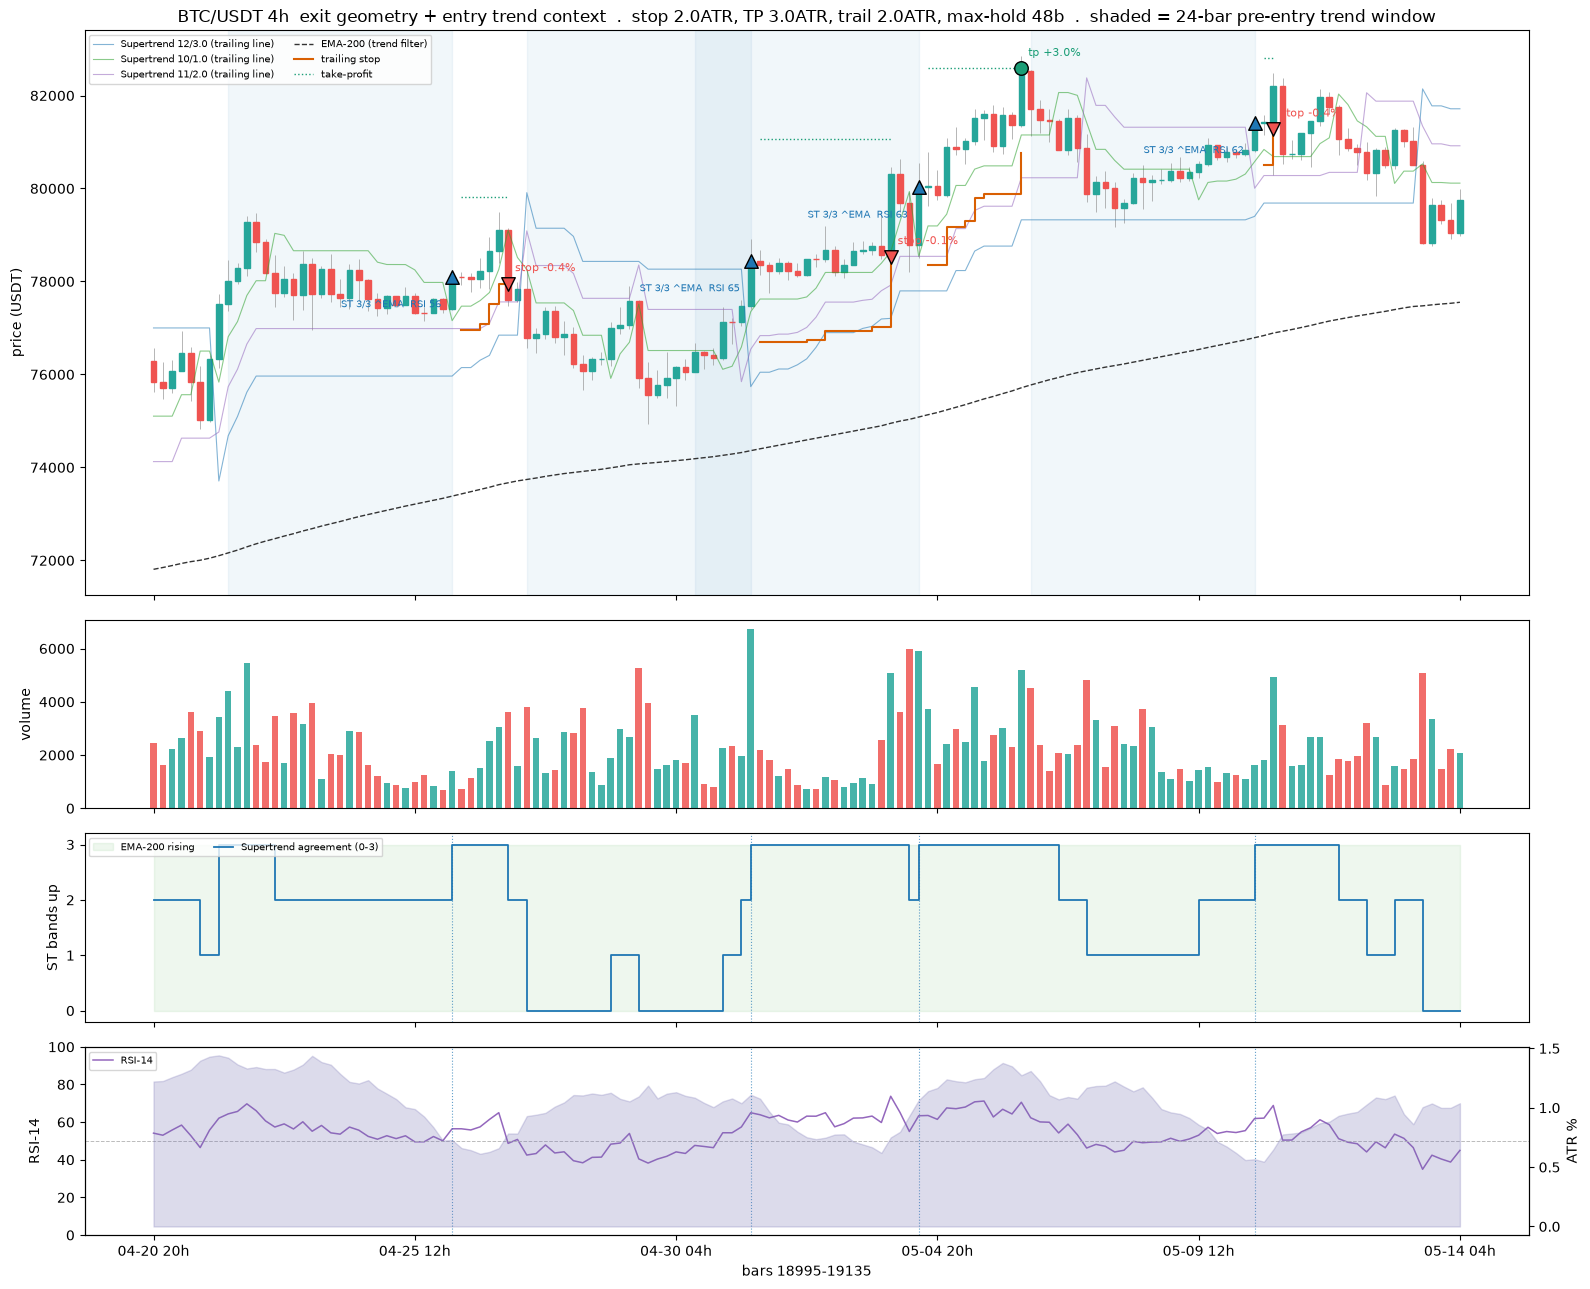

[compare] BTC/USDT 4h: anchored on entry at bar 19113


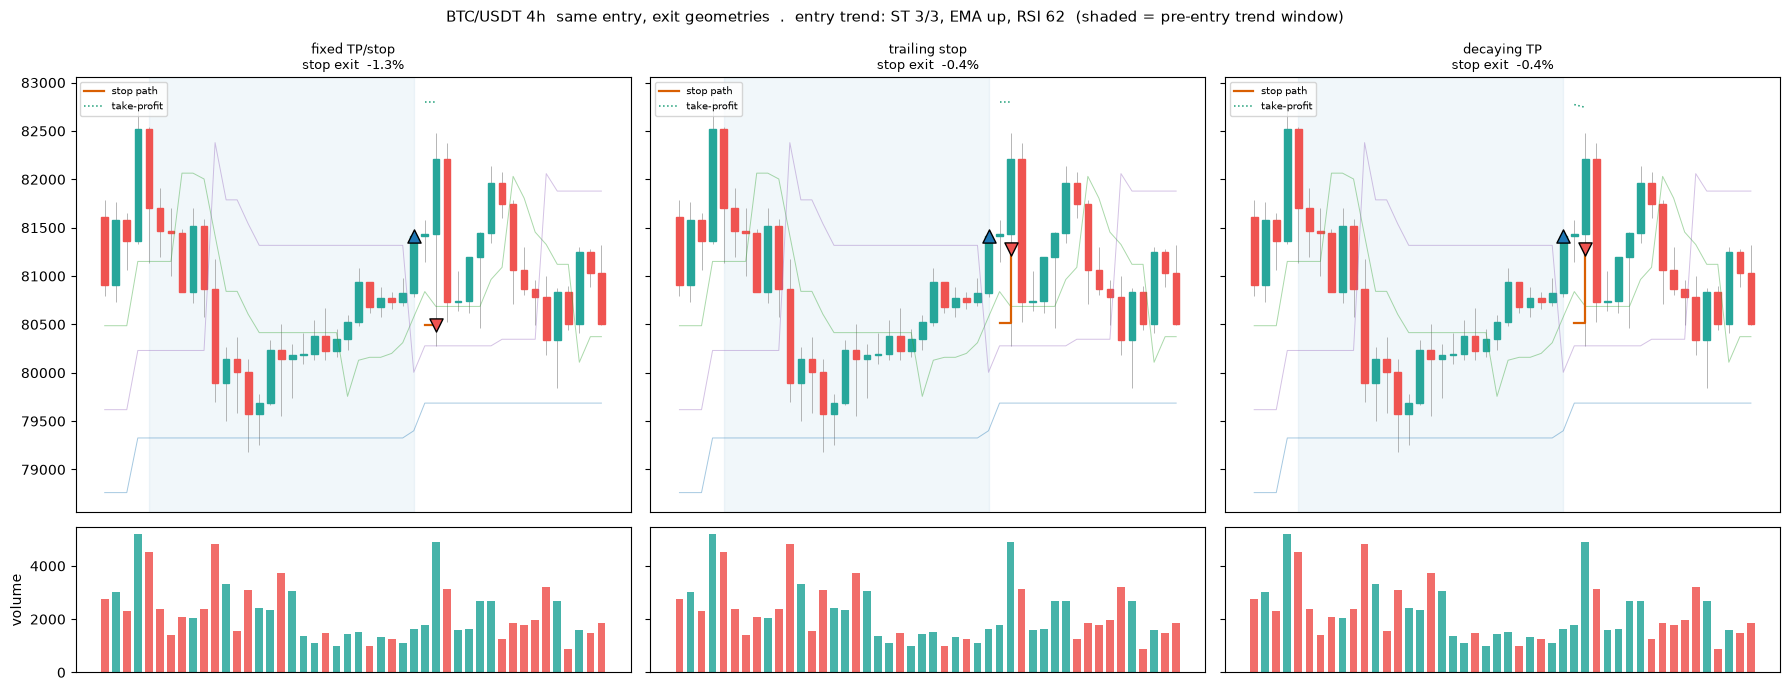

In [11]:
# Exit geometry + entry trend context (single source: inputs/exit_geometry_viz.py)
import os, sys
for _up in (".", "..", "../.."):
    _cand = os.path.abspath(os.path.join(_up, "inputs"))
    if os.path.isdir(_cand):
        sys.path.insert(0, _cand); break
import exit_geometry_viz as egv
egv.render("BTC/USDT", frame=4, show=True, save=False)   # display inline; chapter three saves the PNGs

### Baseline signals 

These scores are a legible, not-yet-validated read of the signal stack, kept for intuition. They are not a trade trigger. Chapter Three is where any signal must clear the after-fee, out-of-sample, survivorship-complete bar, and on the 1h frame the verdict so far is NO-GO. Read a green cell here as "worth a look", not "buy".

The board's long and short flags combine three indicators on the last daily bar: the Archer MA trend flag (`AMAT`), EMA-14 leading the Kalman mean (`EMA_gt_Kalman`), and price holding above the Kalman mean (`Low_gt_Kalman`). A long is flagged only when all three agree, a short only when none do. MACD, Bollinger, Ichimoku, RSI, Choppiness, and the doji and engulfing candle checks are reported next to them as context, not as votes.

The aligned baseline is the **triple-Supertrend**, the exact rules benchmark Chapter Three scores after fees and the live bot trails (`ST_buy`, `ST_agree`): all three Supertrend bands in an uptrend and price above the EMA-200. The board ranks on this first, so Chapter One and Chapter Three share one baseline rather than each carrying a different rule set. Aligning the two also fixes the older description in this section, which listed MACD, a moving-average crossover, a Fibonacci pocket, and an engulfing candle as the four votes: that scheme never matched the code, which scores AMAT, the EMA-Kalman lead, and the Kalman level.

A note retained from the first build: on 06/18/2026 a candle bug that swapped open and close prices was found and corrected, so the engulfing checks now follow the standard definition on valid columns.

In [12]:
stamp = datetime.now().strftime('%Y%m%d')
path = f'../outputs/CSV/DailySignals_{stamp}.csv'
results.to_csv(path, index=False)
print("saved", path)

saved ../outputs/CSV/DailySignals_20260630.csv


### Decision Checklist

These steps are illustrative, a way to read the board, not a trade trigger; sizing and fee controls live in Chapter Two and the after-fee, out-of-sample verdict in Chapter Three.

1. Read exits (`bottom`) before entries (`top`).
2. Treat a green cell as "worth a look", then check it against the Chapter Three evaluation.
3. Size and risk-fence in Chapter Two before acting.
4. Widen timelines and trend comparisons; all board snapshots are saved and dated under `/outputs/`.

##### Report Formats

 - `quarto preview 01-trader-metrics.ipynb --no-execute`
 - `quarto render 01-trader-metrics.ipynb --to html --no-execute`
 - `quarto render 01-trader-metrics.ipynb --to docx --no-execute`
 - `quarto render 01-trader-metrics.ipynb --to pdf --no-execute`